# Revised Phase 4: Deconfounded Temporal Ablation

## Required input files for this notebook

**Run these data notebooks first:**

1. `Data_Extraction_Yahoo_Market_BTC_ETH.ipynb`
2. `Data_Extraction_AlphaVantage_Premium_Before_2025_10.ipynb`
3. `Data_Extraction_AlphaVantage_Premium_After_2025_10.ipynb`

Required files:

- `/content/drive/MyDrive/Crypto_Research/data/market/BTC_market.csv`
- `/content/drive/MyDrive/Crypto_Research/data/market/ETH_market.csv`
- `/content/drive/MyDrive/Crypto_Research/data/market/selected_market_features.json`
- `/content/drive/MyDrive/Crypto_Research/data/alphavantage_news/alphavantage_BTC_crypto_articles_finbert.csv`
- `/content/drive/MyDrive/Crypto_Research/data/alphavantage_news/alphavantage_ETH_crypto_articles_finbert.csv`

**SOL is not used in the revised main study.**

**Pre-model news cleaning:** BTC- and ETH-specific FinBERT corpora receive the same full-period duplicate-control and automated-market-recap exclusion before daily sentiment aggregation. Existing FinBERT scores are reused; no FinBERT inference is performed here. The exact preprocessing counts are saved to `news_preprocessing_audit.csv`.

Normal MarketWatch editorial articles are retained. Explicit automation metadata is used when available; otherwise a conservative MarketWatch-only `data-news` URL / recap-title-template fallback is applied.

The original Phase 4 changed lookback, decay weighting, and model hyperparameters simultaneously. This notebook keeps the model specifications fixed and separately evaluates shorter lookback only, decay only, and the combined temporal treatment.


**FinBERT schema compatibility:** this version reads the extraction columns `finbert_sentiment_score`, `finbert_positive`, `finbert_negative`, and `finbert_neutral`. When no explicit confidence field is present, confidence is computed as the maximum of the three FinBERT class probabilities.


In [1]:
# Common utilities for the revised HICSS experiments.
# The code is intentionally duplicated inside each notebook so every notebook can run independently.

import json
import os
import platform
import random
import re
import warnings
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import binomtest, wilcoxon
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.arima.model import ARIMA

try:
    import tensorflow as tf
    from tensorflow.keras.callbacks import EarlyStopping
    from tensorflow.keras.layers import Dense, Dropout, Input, LSTM
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.optimizers import Adam
    TF_AVAILABLE = True
except ImportError:
    tf = None
    EarlyStopping = Dense = Dropout = Input = LSTM = Sequential = Adam = None
    TF_AVAILABLE = False

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBRegressor = None
    XGBOOST_AVAILABLE = False

warnings.filterwarnings("ignore")

# Mount Google Drive when running in Colab.
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass


# -----------------------------------------------------------------------------
# Reproducibility and file handling
# -----------------------------------------------------------------------------

def set_seed(seed: int) -> None:
    """Set Python, NumPy, and TensorFlow seeds when TensorFlow is available."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["TF_DETERMINISTIC_OPS"] = "1"
    os.environ["TF_CUDNN_DETERMINISTIC"] = "1"
    random.seed(seed)
    np.random.seed(seed)
    if TF_AVAILABLE:
        tf.random.set_seed(seed)

def ensure_output_directory(path: Path) -> Path:
    """Create an output directory when it does not already exist."""
    path.mkdir(parents=True, exist_ok=True)
    return path


def save_configuration(config: Dict, output_path: Path) -> None:
    """Save the exact experiment configuration used by the notebook."""
    serializable = {}
    for key, value in config.items():
        if isinstance(value, Path):
            serializable[key] = str(value)
        elif isinstance(value, pd.Timestamp):
            serializable[key] = value.isoformat()
        else:
            serializable[key] = value
    with output_path.open("w", encoding="utf-8") as handle:
        json.dump(serializable, handle, indent=2, default=str)


def save_environment_manifest(output_path: Path) -> None:
    """Save package versions for reproducibility."""
    manifest = {
        "python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "tensorflow": tf.__version__ if TF_AVAILABLE else "not installed",
    }
    try:
        import sklearn
        import scipy
        import statsmodels
        import xgboost

        manifest.update(
            {
                "scikit_learn": sklearn.__version__,
                "scipy": scipy.__version__,
                "statsmodels": statsmodels.__version__,
                "xgboost": xgboost.__version__,
            }
        )
    except Exception:
        pass
    with output_path.open("w", encoding="utf-8") as handle:
        json.dump(manifest, handle, indent=2)

# -----------------------------------------------------------------------------
# Date normalization and data loading
# -----------------------------------------------------------------------------

def normalize_daily_dates(values: pd.Series) -> pd.Series:
    """Convert date or timestamp values to normalized UTC calendar dates."""
    parsed = pd.to_datetime(values, errors="coerce", utc=True)
    return parsed.dt.tz_convert("UTC").dt.tz_localize(None).dt.normalize()


def find_date_column(df: pd.DataFrame) -> str:
    """Return the first supported date column name."""
    for candidate in [
        "Date",
        "date",
        "Target_Date",
        "pub_date",
        "pubDate",
        "time_published",
        "published_at_utc",
        "published_at",
        "datetime",
        "timestamp",
    ]:
        if candidate in df.columns:
            return candidate
    raise ValueError(
        "No supported date column was found. Expected a Date/date/pub_date/pubDate/time_published/"
        "published_at_utc/published_at/datetime/timestamp column."
    )


# Store one reproducible audit row for each article-level corpus loaded in this notebook.
_NEWS_PREPROCESSING_AUDIT = []


def normalize_title_for_training_dedup(value) -> str:
    """Normalize news titles for transparent full-period duplicate control."""
    if pd.isna(value):
        return ""
    text = str(value).lower().strip()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", "", text)
    return text.strip()


def deduplicate_news_articles(frame: pd.DataFrame, date_column: str):
    """
    Remove repeated article-level news records before daily aggregation.

    The rule is applied uniformly to the entire study history:
    1. exact article_id/news_id duplicates when an identifier is available;
    2. same normalized title + same source + same UTC publication day.

    Missing titles are never collapsed together; they fall back to an available
    article identifier, URL, or row-specific key.

    Returns
    -------
    cleaned : pd.DataFrame
    stats : dict
        Row counts for the preprocessing audit.
    """
    if frame.empty:
        return frame.copy(), {
            "input_rows": 0,
            "after_exact_id_rows": 0,
            "after_title_source_day_rows": 0,
            "exact_id_removed": 0,
            "title_source_day_removed": 0,
        }

    working = frame.copy()
    input_rows = len(working)

    id_column = next(
        (
            column
            for column in ["article_id", "news_id"]
            if column in working.columns and working[column].notna().any()
        ),
        None,
    )
    if id_column is not None:
        working = working.drop_duplicates(subset=[id_column], keep="last")
    after_exact_id_rows = len(working)

    if "title" not in working.columns:
        cleaned = working.reset_index(drop=True)
        stats = {
            "input_rows": input_rows,
            "after_exact_id_rows": after_exact_id_rows,
            "after_title_source_day_rows": len(cleaned),
            "exact_id_removed": input_rows - after_exact_id_rows,
            "title_source_day_removed": after_exact_id_rows - len(cleaned),
        }
        return cleaned, stats

    source_column = next(
        (column for column in ["source", "source_domain"] if column in working.columns),
        None,
    )
    if source_column is None:
        working["__news_source_normalized"] = ""
    else:
        working["__news_source_normalized"] = (
            working[source_column].fillna("").astype(str).str.lower().str.strip()
        )

    working["__news_title_normalized"] = working["title"].apply(
        normalize_title_for_training_dedup
    )
    working["__news_publication_day"] = pd.to_datetime(
        working[date_column], errors="coerce"
    ).dt.strftime("%Y-%m-%d")

    missing_title = working["__news_title_normalized"].eq("")
    if missing_title.any():
        if id_column is not None:
            fallback = working[id_column].astype(str)
        elif "url" in working.columns:
            fallback = working["url"].fillna("").astype(str)
        else:
            fallback = working.index.to_series().astype(str)
        working.loc[missing_title, "__news_title_normalized"] = (
            "__missing_title__" + fallback.loc[missing_title]
        )

    working = working.sort_values(date_column).drop_duplicates(
        subset=[
            "__news_title_normalized",
            "__news_source_normalized",
            "__news_publication_day",
        ],
        keep="first",
    )

    working = working.drop(
        columns=[
            "__news_title_normalized",
            "__news_source_normalized",
            "__news_publication_day",
        ]
    ).reset_index(drop=True)

    after_title_source_day_rows = len(working)
    stats = {
        "input_rows": input_rows,
        "after_exact_id_rows": after_exact_id_rows,
        "after_title_source_day_rows": after_title_source_day_rows,
        "exact_id_removed": input_rows - after_exact_id_rows,
        "title_source_day_removed": after_exact_id_rows - after_title_source_day_rows,
    }
    print(
        f"Training-time news de-duplication: {input_rows:,} -> "
        f"{after_title_source_day_rows:,} rows "
        f"({input_rows - after_title_source_day_rows:,} removed)."
    )
    return working, stats


def identify_automated_market_recaps(frame: pd.DataFrame):
    """
    Identify MarketWatch automated market-recap records without removing normal
    MarketWatch editorial articles.

    Preferred rule: explicit author metadata containing 'MarketWatch Automation'.
    The current extraction masters may not contain an authors column, so a
    conservative fallback is used only for MarketWatch rows: the known
    marketwatch.com/data-news URL path and/or highly templated stock-recap titles.
    """
    if frame.empty or not FILTER_AUTOMATED_MARKET_RECAPS:
        return pd.Series(False, index=frame.index), "disabled"

    source_column = next(
        (column for column in ["source", "source_domain"] if column in frame.columns),
        None,
    )
    if source_column is None:
        return pd.Series(False, index=frame.index), "no_source_metadata"

    source_text = frame[source_column].fillna("").astype(str).str.lower().str.strip()
    is_marketwatch = source_text.str.contains("marketwatch", regex=False)

    author_column = next(
        (column for column in ["authors", "author", "byline"] if column in frame.columns),
        None,
    )
    if author_column is not None:
        author_text = frame[author_column].fillna("").astype(str).str.lower()
        explicit = is_marketwatch & author_text.str.contains(
            MARKETWATCH_AUTOMATION_AUTHOR_TOKEN, regex=False
        )
        if explicit.any():
            return explicit, "explicit_author_metadata"

    url_match = pd.Series(False, index=frame.index)
    if "url" in frame.columns:
        urls = frame["url"].fillna("").astype(str).str.lower()
        url_match = urls.str.contains("marketwatch.com/data-news/", regex=False)

    title_match = pd.Series(False, index=frame.index)
    if "title" in frame.columns:
        titles = frame["title"].fillna("").astype(str).str.lower()
        title_match = titles.str.contains(MARKETWATCH_RECAP_TITLE_REGEX, regex=True, na=False)

    fallback = is_marketwatch & (url_match | title_match)
    return fallback, "marketwatch_data_news_or_template_fallback"


def remove_automated_market_recaps(frame: pd.DataFrame):
    """Exclude identified automated market recaps before daily sentiment aggregation."""
    if frame.empty:
        return frame.copy(), {"automated_removed": 0, "automated_filter_method": "empty"}

    mask, method = identify_automated_market_recaps(frame)
    removed = int(mask.sum())
    cleaned = frame.loc[~mask].copy().reset_index(drop=True)

    print(
        f"Automated market-recap filtering [{method}]: "
        f"{len(frame):,} -> {len(cleaned):,} rows ({removed:,} removed)."
    )
    if method.endswith("fallback"):
        warnings.warn(
            "No explicit MarketWatch Automation author metadata was available in this corpus. "
            "A conservative MarketWatch-only URL/title-template fallback was used."
        )

    return cleaned, {
        "automated_removed": removed,
        "automated_filter_method": method,
    }

def load_and_combine_csv_files(
    file_paths: Sequence[Path],
    end_date: pd.Timestamp,
    date_output_name: str = "Date",
    deduplicate_dates: bool = True,
) -> pd.DataFrame:
    """Load one or more legacy train/test CSV files and rebuild one chronological dataset."""
    frames = []
    missing = []
    for path in file_paths:
        if path.exists():
            frame = pd.read_csv(path)
            frame["__source_file"] = path.name
            frames.append(frame)
        else:
            missing.append(str(path))

    if not frames:
        raise FileNotFoundError(
            "None of the configured input files were found:\n- " + "\n- ".join(missing)
        )

    if missing:
        warnings.warn("Some configured files were not found and were skipped:\n- " + "\n- ".join(missing))

    combined = pd.concat(frames, ignore_index=True, sort=False)
    date_column = find_date_column(combined)
    combined[date_output_name] = normalize_daily_dates(combined[date_column])
    combined = combined.dropna(subset=[date_output_name])
    combined = combined[combined[date_output_name] <= end_date].copy()
    combined = combined.sort_values(date_output_name)
    if deduplicate_dates:
        combined = combined.drop_duplicates(subset=[date_output_name], keep="last")
        combined = combined.reset_index(drop=True)
    else:
        # Article-level news: apply one uniform duplicate rule across the full study period,
        # then remove identified automated market recaps before daily sentiment aggregation.
        corpus_name = " | ".join(sorted(combined["__source_file"].astype(str).unique().tolist()))
        combined, dedup_stats = deduplicate_news_articles(combined, date_output_name)
        combined, automated_stats = remove_automated_market_recaps(combined)
        _NEWS_PREPROCESSING_AUDIT.append(
            {
                "corpus": corpus_name,
                **dedup_stats,
                **automated_stats,
                "final_rows": len(combined),
            }
        )

    if combined.empty:
        raise ValueError("The combined dataset is empty after date parsing and end-date filtering.")

    actual_end = combined[date_output_name].max()
    if actual_end < end_date:
        warnings.warn(
            f"Configured end date is {end_date.date()}, but the latest available row is {actual_end.date()}."
        )

    return combined


def validate_single_provider(
    df: pd.DataFrame,
    expected_provider: str,
    provider_columns: Sequence[str] = ("provider", "news_provider", "api_provider", "dataset_provider"),
) -> None:
    """Check that all news-derived rows identify one API provider when provider metadata is available."""
    provider_column = next((column for column in provider_columns if column in df.columns), None)
    if provider_column is None:
        warnings.warn(
            "No news-provider metadata column was found. Add a constant news_provider column to the "
            "prepared files so the single-source design can be verified."
        )
        return

    observed = sorted(df[provider_column].dropna().astype(str).str.strip().unique().tolist())
    if len(observed) > 1:
        raise ValueError(f"Multiple news providers were found in {provider_column}: {observed}")
    if observed and expected_provider and observed[0].lower() != expected_provider.lower():
        warnings.warn(
            f"The file reports provider '{observed[0]}', while EXPECTED_NEWS_PROVIDER is "
            f"'{expected_provider}'. Confirm the configuration before running the final study."
        )


# -----------------------------------------------------------------------------
# Market feature preparation and target definition
# -----------------------------------------------------------------------------

def calculate_rsi(close: pd.Series, window: int = 14) -> pd.Series:
    """Calculate the relative strength index from close prices."""
    difference = close.diff()
    gains = difference.clip(lower=0)
    losses = -difference.clip(upper=0)
    average_gain = gains.rolling(window=window, min_periods=window).mean()
    average_loss = losses.rolling(window=window, min_periods=window).mean()
    relative_strength = average_gain / average_loss.replace(0, np.nan)
    return 100 - (100 / (1 + relative_strength))


def ensure_market_features(df: pd.DataFrame) -> pd.DataFrame:
    """Create missing baseline variables without overwriting existing prepared columns."""
    prepared = df.copy()
    if "Date" not in prepared.columns:
        date_column = find_date_column(prepared)
        prepared["Date"] = normalize_daily_dates(prepared[date_column])
    else:
        prepared["Date"] = normalize_daily_dates(prepared["Date"])

    if "Close" not in prepared.columns:
        for candidate in ["close", "Adj Close", "adj_close"]:
            if candidate in prepared.columns:
                prepared["Close"] = pd.to_numeric(prepared[candidate], errors="coerce")
                break
    if "Close" not in prepared.columns:
        raise ValueError("A Close price column is required.")

    prepared["Close"] = pd.to_numeric(prepared["Close"], errors="coerce")
    prepared = prepared.sort_values("Date").drop_duplicates("Date", keep="last").reset_index(drop=True)

    if "Daily_Return" not in prepared.columns:
        prepared["Daily_Return"] = prepared["Close"].pct_change()
    if "Return_lag1" not in prepared.columns:
        prepared["Return_lag1"] = prepared["Daily_Return"].shift(1)
    if "Return_lag3" not in prepared.columns:
        prepared["Return_lag3"] = prepared["Daily_Return"].shift(3)
    if "Return_lag5" not in prepared.columns:
        prepared["Return_lag5"] = prepared["Daily_Return"].shift(5)
    if "MA_20" not in prepared.columns:
        prepared["MA_20"] = prepared["Close"].rolling(20, min_periods=20).mean()
    if "RSI" not in prepared.columns:
        prepared["RSI"] = calculate_rsi(prepared["Close"], window=14)
    if "volatility_20d" not in prepared.columns:
        prepared["volatility_20d"] = prepared["Daily_Return"].rolling(20, min_periods=20).std()

    if "volume_vs_MA5" not in prepared.columns:
        volume_column = next((c for c in ["Volume", "volume"] if c in prepared.columns), None)
        if volume_column is not None:
            volume = pd.to_numeric(prepared[volume_column], errors="coerce")
            prepared["volume_vs_MA5"] = volume / volume.rolling(5, min_periods=5).mean()

    # Forward filling is allowed only for market-wide daily series that are not published on weekends.
    for column in ["SP500Close", "VIXClose"]:
        if column in prepared.columns:
            prepared[column] = pd.to_numeric(prepared[column], errors="coerce").ffill()

    prepared["Log_Return"] = np.log(prepared["Close"]).diff()
    prepared["Target_Log_Return"] = np.log(prepared["Close"].shift(-1) / prepared["Close"])
    prepared["Target_Close"] = prepared["Close"].shift(-1)
    prepared["Target_Date"] = prepared["Date"].shift(-1)

    prepared = prepared.replace([np.inf, -np.inf], np.nan)
    return prepared


def available_features(df: pd.DataFrame, requested: Sequence[str]) -> List[str]:
    """Return requested features that are available and warn about missing columns."""
    selected = [column for column in requested if column in df.columns]
    missing = [column for column in requested if column not in df.columns]
    if missing:
        warnings.warn("The following requested features are unavailable and will be omitted: " + ", ".join(missing))
    if not selected:
        raise ValueError("No requested feature columns are available.")
    return selected


def add_zero_filled_news_features(df: pd.DataFrame, feature_columns: Sequence[str]) -> pd.DataFrame:
    """Fill no-news days with zero without using future observations."""
    prepared = df.copy()
    for column in feature_columns:
        if column in prepared.columns:
            prepared[column] = pd.to_numeric(prepared[column], errors="coerce").fillna(0.0)
    return prepared


# -----------------------------------------------------------------------------
# FinBERT aggregation helpers used by Phase 2, Phase 3, and Phase 4
# -----------------------------------------------------------------------------

def aggregate_wide_finbert_features(df: pd.DataFrame) -> pd.DataFrame:
    """Create the three original FinBERT features from wide daily article columns when needed."""
    prepared = df.copy()
    required = ["weighted_sentiment", "sentiment_volatility", "sentiment_momentum_3d"]
    if all(column in prepared.columns for column in required):
        return prepared

    sentiment_columns = sorted([c for c in prepared.columns if "finbert_sentiment" in c.lower()])
    confidence_columns = sorted([c for c in prepared.columns if "finbert_confidence" in c.lower()])
    if not sentiment_columns:
        score_fallback = next((c for c in ["finbert_sentiment_score", "finbert_score"] if c in prepared.columns), None)
        if score_fallback is not None:
            prepared["weighted_sentiment"] = pd.to_numeric(prepared[score_fallback], errors="coerce").fillna(0.0)
            prepared["sentiment_volatility"] = 0.0
            prepared["sentiment_momentum_3d"] = prepared["weighted_sentiment"].diff(3).fillna(0.0)
            return prepared
        raise ValueError(
            "FinBERT columns were not found. Provide weighted_sentiment/sentiment_volatility/"
            "sentiment_momentum_3d or matching finbert_sentiment_* and finbert_confidence_* columns."
        )

    weighted_values = []
    dispersion_values = []
    for _, row in prepared.iterrows():
        scores = []
        weights = []
        for index, sentiment_column in enumerate(sentiment_columns):
            value = pd.to_numeric(pd.Series([row[sentiment_column]]), errors="coerce").iloc[0]
            if pd.isna(value):
                continue
            if index < len(confidence_columns):
                weight = pd.to_numeric(pd.Series([row[confidence_columns[index]]]), errors="coerce").iloc[0]
            else:
                weight = 1.0
            if pd.isna(weight) or weight <= 0:
                weight = 1.0
            scores.append(float(value))
            weights.append(float(weight))
        if scores:
            weighted_values.append(float(np.average(scores, weights=weights)))
            dispersion_values.append(float(np.std(scores)) if len(scores) > 1 else 0.0)
        else:
            weighted_values.append(0.0)
            dispersion_values.append(0.0)

    prepared["weighted_sentiment"] = weighted_values
    prepared["sentiment_volatility"] = dispersion_values
    prepared["sentiment_momentum_3d"] = prepared["weighted_sentiment"].diff(3).fillna(0.0)
    return prepared


def aggregate_article_api_sentiment_files(
    file_paths: Sequence[Path],
    end_date: pd.Timestamp,
    expected_provider: str,
) -> pd.DataFrame:
    """Aggregate Alpha Vantage article-level sentiment into the original Phase 1 daily features."""
    articles = load_and_combine_csv_files(
        file_paths,
        end_date=end_date,
        date_output_name="date",
        deduplicate_dates=False,
    )
    validate_single_provider(articles, expected_provider=expected_provider)

    score_column = next(
        (
            column
            for column in [
                "perigon_sentiment_score",
                "api_sentiment_score",
                "overall_sentiment_score",
                "sentiment_score",
            ]
            if column in articles.columns
        ),
        None,
    )
    if score_column is None:
        positive_column = next(
            (column for column in ["perigon_positive", "positive_sentiment"] if column in articles.columns),
            None,
        )
        negative_column = next(
            (column for column in ["perigon_negative", "negative_sentiment"] if column in articles.columns),
            None,
        )
        if positive_column is None or negative_column is None:
            raise ValueError(
                "Phase 1 article files require an API/overall sentiment score "
                "or positive and negative sentiment probability columns."
            )
        articles["__api_sentiment_score"] = (
            pd.to_numeric(articles[positive_column], errors="coerce")
            - pd.to_numeric(articles[negative_column], errors="coerce")
        )
        score_column = "__api_sentiment_score"

    confidence_column = next(
        (
            column
            for column in [
                "perigon_sentiment_confidence",
                "api_sentiment_confidence",
                "sentiment_confidence",
            ]
            if column in articles.columns
        ),
        None,
    )
    articles[score_column] = pd.to_numeric(articles[score_column], errors="coerce")
    if confidence_column is None:
        articles["__api_confidence"] = 1.0
        confidence_column = "__api_confidence"
    else:
        articles[confidence_column] = pd.to_numeric(
            articles[confidence_column], errors="coerce"
        ).fillna(1.0)

    rows = []
    for date, group in articles.groupby("date", sort=True):
        valid = group[[score_column, confidence_column]].dropna(subset=[score_column])
        if valid.empty:
            rows.append(
                {
                    "Date": pd.Timestamp(date),
                    "total_news_count": 0,
                    "overall_avg_sentiment": 0.0,
                    "weighted_sentiment": 0.0,
                }
            )
            continue

        scores = valid[score_column].to_numpy(dtype=float)
        weights = valid[confidence_column].clip(lower=1e-8).to_numpy(dtype=float)
        rows.append(
            {
                "Date": pd.Timestamp(date),
                "total_news_count": int(len(scores)),
                "overall_avg_sentiment": float(np.mean(scores)),
                "weighted_sentiment": float(np.average(scores, weights=weights)),
            }
        )

    return pd.DataFrame(rows).sort_values("Date").reset_index(drop=True)


def aggregate_article_finbert_files(
    file_paths: Sequence[Path],
    end_date: pd.Timestamp,
    expected_provider: str,
) -> pd.DataFrame:
    """Aggregate article-level FinBERT outputs into three daily sentiment features.

    The Alpha Vantage extraction notebooks save ProsusAI/finbert outputs as
    finbert_positive, finbert_negative, finbert_neutral, and
    finbert_sentiment_score = finbert_positive - finbert_negative.
    When an explicit confidence column is unavailable, article confidence is
    defined as max(P_positive, P_negative, P_neutral).
    """
    articles = load_and_combine_csv_files(
        file_paths,
        end_date=end_date,
        date_output_name="date",
        deduplicate_dates=False,
    )
    validate_single_provider(articles, expected_provider=expected_provider)

    score_column = next(
        (
            column
            for column in [
                "finbert_sentiment_score",
                "finbert_score",
                "sentiment_score",
                "FinBERT_Score",
            ]
            if column in articles.columns
        ),
        None,
    )
    if score_column is None:
        raise ValueError(
            "Article-level news files require a FinBERT sentiment-score column. "
            "Expected finbert_sentiment_score (current extraction schema) or a supported legacy name."
        )

    articles[score_column] = pd.to_numeric(articles[score_column], errors="coerce")

    confidence_column = next(
        (
            column
            for column in [
                "finbert_confidence",
                "sentiment_confidence",
                "FinBERT_Confidence",
            ]
            if column in articles.columns
        ),
        None,
    )

    probability_columns = [
        "finbert_positive",
        "finbert_negative",
        "finbert_neutral",
    ]
    if confidence_column is None and all(
        column in articles.columns for column in probability_columns
    ):
        for column in probability_columns:
            articles[column] = pd.to_numeric(articles[column], errors="coerce")
        articles["__finbert_confidence"] = articles[probability_columns].max(axis=1)
        confidence_column = "__finbert_confidence"
    elif confidence_column is None:
        # Backward-compatible fallback for older FinBERT files that do not store
        # class probabilities. Current Alpha Vantage extraction files should not
        # normally use this branch.
        articles["__confidence"] = 1.0
        confidence_column = "__confidence"
    else:
        articles[confidence_column] = pd.to_numeric(
            articles[confidence_column], errors="coerce"
        ).fillna(1.0)

    rows = []
    for date, group in articles.groupby("date", sort=True):
        valid = group[[score_column, confidence_column]].dropna(subset=[score_column])
        if valid.empty:
            weighted_sentiment = 0.0
            sentiment_volatility = 0.0
            count = 0
        else:
            weights = (
                pd.to_numeric(valid[confidence_column], errors="coerce")
                .fillna(1.0)
                .clip(lower=1e-8)
                .to_numpy(dtype=float)
            )
            scores = pd.to_numeric(valid[score_column], errors="coerce").to_numpy(dtype=float)
            weighted_sentiment = float(np.average(scores, weights=weights))
            sentiment_volatility = float(np.std(scores)) if len(scores) > 1 else 0.0
            count = int(len(scores))
        rows.append(
            {
                "Date": pd.Timestamp(date),
                "weighted_sentiment": weighted_sentiment,
                "sentiment_volatility": sentiment_volatility,
                "news_count": count,
            }
        )

    daily = pd.DataFrame(rows).sort_values("Date").reset_index(drop=True)
    daily["sentiment_momentum_3d"] = daily["weighted_sentiment"].diff(3).fillna(0.0)
    return daily
def merge_daily_sentiment(
    market_df: pd.DataFrame,
    sentiment_df: pd.DataFrame,
    prefix: str,
) -> Tuple[pd.DataFrame, List[str]]:
    """Merge daily sentiment into market data and prefix the three sentiment variables."""
    sentiment_columns = ["weighted_sentiment", "sentiment_volatility", "sentiment_momentum_3d"]
    renamed = {column: f"{prefix}{column}" for column in sentiment_columns if column in sentiment_df.columns}
    daily = sentiment_df[["Date"] + list(renamed.keys())].rename(columns=renamed)
    merged = market_df.merge(daily, on="Date", how="left", validate="one_to_one")
    new_columns = list(renamed.values())
    merged = add_zero_filled_news_features(merged, new_columns)
    return merged, new_columns


# -----------------------------------------------------------------------------
# Chronological split and sequence construction
# -----------------------------------------------------------------------------

def validate_split_dates(split_dates: Dict[str, pd.Timestamp]) -> Dict[str, pd.Timestamp]:
    """Validate and normalize one fixed chronological target-date split."""
    required = [
        "train_start",
        "train_end",
        "validation_start",
        "validation_end",
        "test_start",
        "test_end",
    ]
    missing = [key for key in required if key not in split_dates]
    if missing:
        raise ValueError("Missing split-date keys: " + ", ".join(missing))

    normalized = {key: pd.Timestamp(split_dates[key]).normalize() for key in required}
    if not (
        normalized["train_start"] <= normalized["train_end"]
        < normalized["validation_start"] <= normalized["validation_end"]
        < normalized["test_start"] <= normalized["test_end"]
    ):
        raise ValueError("Train, validation, and test dates must be strictly chronological and non-overlapping.")
    return normalized


def assign_split_labels(
    df: pd.DataFrame,
    split_dates: Dict[str, pd.Timestamp],
) -> pd.DataFrame:
    """Assign train, validation, and test labels using forecast target dates."""
    dates = validate_split_dates(split_dates)
    labeled = df.copy().reset_index(drop=True)
    labeled["Target_Date"] = normalize_daily_dates(labeled["Target_Date"])
    labels = np.full(len(labeled), "excluded", dtype=object)

    target_dates = labeled["Target_Date"]
    labels[target_dates < dates["train_start"]] = "warmup"
    labels[
        (target_dates >= dates["train_start"]) & (target_dates <= dates["train_end"])
    ] = "train"
    labels[
        (target_dates >= dates["validation_start"])
        & (target_dates <= dates["validation_end"])
    ] = "validation"
    labels[
        (target_dates >= dates["test_start"]) & (target_dates <= dates["test_end"])
    ] = "test"
    labeled["split"] = labels
    return labeled


def validate_split_counts(df: pd.DataFrame, split_dates: Dict[str, pd.Timestamp]) -> pd.DataFrame:
    """Return split counts and fail when a required segment has no usable observations."""
    labeled = assign_split_labels(df, split_dates)
    counts = labeled["split"].value_counts().reindex(
        ["warmup", "train", "validation", "test", "excluded"], fill_value=0
    )
    for split in ["train", "validation", "test"]:
        if int(counts[split]) == 0:
            raise ValueError(f"No usable observations fall in the configured {split} target-date period.")
    return counts.rename_axis("split").reset_index(name="observation_count")


def make_recency_weights(lookback: int, decay_rate: float) -> np.ndarray:
    """Create the original exponentially decaying sequence weights."""
    weights = np.array([decay_rate ** (lookback - index - 1) for index in range(lookback)], dtype=float)
    return weights / weights.sum()


def build_sequence_bundle(
    df: pd.DataFrame,
    feature_columns: Sequence[str],
    lookback: int,
    split_dates: Dict[str, pd.Timestamp],
    use_weighting: bool = False,
    decay_rate: float = 0.95,
) -> Dict:
    """Create leakage-safe LSTM/XGBoost sequences using fixed target-date splits."""
    required_columns = list(
        dict.fromkeys(
            list(feature_columns)
            + ["Date", "Target_Date", "Close", "Target_Close", "Target_Log_Return"]
        )
    )
    prepared = df[required_columns].copy()
    prepared = prepared.replace([np.inf, -np.inf], np.nan)
    prepared = prepared.dropna(subset=required_columns).reset_index(drop=True)
    prepared = assign_split_labels(prepared, split_dates)

    training_rows = prepared[prepared["split"] == "train"]
    if training_rows.empty:
        raise ValueError("The configured training period contains no usable rows.")

    feature_scaler = StandardScaler()
    target_scaler = StandardScaler()
    feature_scaler.fit(training_rows[list(feature_columns)])
    target_scaler.fit(training_rows[["Target_Log_Return"]])

    scaled_features = feature_scaler.transform(prepared[list(feature_columns)])
    scaled_target = target_scaler.transform(prepared[["Target_Log_Return"]]).reshape(-1)
    weights = make_recency_weights(lookback, decay_rate) if use_weighting else None

    records = {
        split: {
            "X": [],
            "y": [],
            "actual": [],
            "query_date": [],
            "target_date": [],
            "previous_close": [],
            "actual_close": [],
        }
        for split in ["train", "validation", "test"]
    }

    for end_index in range(lookback - 1, len(prepared)):
        split = prepared.loc[end_index, "split"]
        if split not in records:
            continue
        start_index = end_index - lookback + 1
        sequence = scaled_features[start_index : end_index + 1].copy()
        if use_weighting:
            sequence = sequence * weights[:, np.newaxis]
        records[split]["X"].append(sequence)
        records[split]["y"].append(scaled_target[end_index])
        records[split]["actual"].append(float(prepared.loc[end_index, "Target_Log_Return"]))
        records[split]["query_date"].append(prepared.loc[end_index, "Date"])
        records[split]["target_date"].append(prepared.loc[end_index, "Target_Date"])
        records[split]["previous_close"].append(float(prepared.loc[end_index, "Close"]))
        records[split]["actual_close"].append(float(prepared.loc[end_index, "Target_Close"]))

    for split in records:
        records[split] = {
            key: (
                np.asarray(value)
                if key in {"X", "y", "actual", "previous_close", "actual_close"}
                else np.asarray(value, dtype="datetime64[ns]")
            )
            for key, value in records[split].items()
        }
        if len(records[split]["X"]) == 0:
            raise ValueError(
                f"No {split} sequences were created. Check the date split, missing values, and lookback."
            )

    return {
        "feature_columns": list(feature_columns),
        "feature_scaler": feature_scaler,
        "target_scaler": target_scaler,
        "lookback": lookback,
        "use_weighting": use_weighting,
        "decay_rate": decay_rate,
        "split_dates": validate_split_dates(split_dates),
        "records": records,
    }


def make_walk_forward_split_dates(
    df: pd.DataFrame,
    final_split_dates: Dict[str, pd.Timestamp],
    split_count: int,
) -> List[Dict[str, pd.Timestamp]]:
    """Create expanding-window folds over the fixed final test period."""
    dates = validate_split_dates(final_split_dates)
    labeled = assign_split_labels(df, dates)
    test_dates = np.array(
        sorted(pd.to_datetime(labeled.loc[labeled["split"] == "test", "Target_Date"].dropna().unique()))
    )
    if len(test_dates) == 0:
        return []

    validation_days = (dates["validation_end"] - dates["validation_start"]).days + 1
    folds = []
    for block in np.array_split(test_dates, split_count):
        if len(block) == 0:
            continue
        fold_test_start = pd.Timestamp(block[0]).normalize()
        fold_test_end = pd.Timestamp(block[-1]).normalize()
        fold_validation_end = fold_test_start - pd.Timedelta(days=1)
        fold_validation_start = fold_validation_end - pd.Timedelta(days=validation_days - 1)
        fold_train_end = fold_validation_start - pd.Timedelta(days=1)
        if fold_train_end < dates["train_start"]:
            continue
        folds.append(
            {
                "train_start": dates["train_start"],
                "train_end": fold_train_end,
                "validation_start": fold_validation_start,
                "validation_end": fold_validation_end,
                "test_start": fold_test_start,
                "test_end": fold_test_end,
            }
        )
    return folds


# -----------------------------------------------------------------------------
# Locked forecasting models
# -----------------------------------------------------------------------------

def build_lstm_model(input_shape: Tuple[int, int]):
    """Build the same locked LSTM architecture for every phase."""
    if not TF_AVAILABLE:
        raise ImportError("TensorFlow is required for LSTM experiments. Install it with: pip install tensorflow")
    model = Sequential(
        [
            Input(shape=input_shape),
            LSTM(LOCKED_LSTM_UNITS[0], return_sequences=True),
            Dropout(LOCKED_LSTM_DROPOUT),
            LSTM(LOCKED_LSTM_UNITS[1], return_sequences=True),
            Dropout(LOCKED_LSTM_DROPOUT),
            LSTM(LOCKED_LSTM_UNITS[2]),
            Dropout(LOCKED_LSTM_DROPOUT),
            Dense(25, activation="relu"),
            Dense(1),
        ]
    )
    model.compile(
        optimizer=Adam(learning_rate=LOCKED_LSTM_LEARNING_RATE),
        loss="mse",
        metrics=["mae"],
    )
    return model

def build_xgb_model(seed: int):
    """Build the same locked XGBoost model for every phase."""
    if not XGBOOST_AVAILABLE:
        raise ImportError("XGBoost is required for tree-based experiments. Install it with: pip install xgboost")
    return XGBRegressor(
        n_estimators=LOCKED_XGB_N_ESTIMATORS,
        max_depth=LOCKED_XGB_MAX_DEPTH,
        learning_rate=LOCKED_XGB_LEARNING_RATE,
        subsample=LOCKED_XGB_SUBSAMPLE,
        colsample_bytree=LOCKED_XGB_COLSAMPLE,
        objective="reg:squarederror",
        random_state=seed,
        n_jobs=-1,
        tree_method="hist",
    )

def inverse_target(predictions_scaled: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    """Inverse-transform scaled return forecasts."""
    return scaler.inverse_transform(np.asarray(predictions_scaled).reshape(-1, 1)).reshape(-1)


def fit_predict_lstm(bundle: Dict, seed: int, verbose: int = 0) -> np.ndarray:
    """Use chronological validation for early stopping, then refit on train plus validation."""
    if not TF_AVAILABLE:
        raise ImportError("TensorFlow is required for LSTM experiments. Install it with: pip install tensorflow")
    set_seed(seed)
    tf.keras.backend.clear_session()

    train = bundle["records"]["train"]
    validation = bundle["records"]["validation"]
    test = bundle["records"]["test"]

    provisional = build_lstm_model((bundle["lookback"], train["X"].shape[2]))
    callback = EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=0,
    )
    history = provisional.fit(
        train["X"],
        train["y"],
        validation_data=(validation["X"], validation["y"]),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=False,
        callbacks=[callback],
        verbose=verbose,
    )
    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

    combined_x = np.concatenate([train["X"], validation["X"]], axis=0)
    combined_y = np.concatenate([train["y"], validation["y"]], axis=0)

    set_seed(seed)
    tf.keras.backend.clear_session()
    final_model = build_lstm_model((bundle["lookback"], combined_x.shape[2]))
    final_model.fit(
        combined_x,
        combined_y,
        epochs=max(best_epoch, 1),
        batch_size=BATCH_SIZE,
        shuffle=False,
        verbose=verbose,
    )
    prediction_scaled = final_model.predict(test["X"], verbose=0).reshape(-1)
    return inverse_target(prediction_scaled, bundle["target_scaler"])

def fit_predict_xgb(bundle: Dict, seed: int) -> np.ndarray:
    """Fit the locked XGBoost model on train plus validation and predict the test segment."""
    set_seed(seed)
    train = bundle["records"]["train"]
    validation = bundle["records"]["validation"]
    test = bundle["records"]["test"]

    combined_x = np.concatenate([train["X"], validation["X"]], axis=0)
    combined_y = np.concatenate([train["y"], validation["y"]], axis=0)
    combined_x = combined_x.reshape(combined_x.shape[0], -1)
    test_x = test["X"].reshape(test["X"].shape[0], -1)

    model = build_xgb_model(seed)
    model.fit(combined_x, combined_y)
    prediction_scaled = model.predict(test_x)
    return inverse_target(prediction_scaled, bundle["target_scaler"])


# -----------------------------------------------------------------------------
# Random-walk and ARIMA benchmarks
# -----------------------------------------------------------------------------

def rolling_arima_forecast(history: Sequence[float], evaluation: Sequence[float], order: Tuple[int, int, int]) -> np.ndarray:
    """Produce one-step-ahead ARIMA forecasts while updating only with realized past returns."""
    history_values = [float(value) for value in history if np.isfinite(value)]
    evaluation_values = [float(value) for value in evaluation]
    predictions = []
    try:
        fitted = ARIMA(history_values, order=order, trend="n").fit()
        for actual in evaluation_values:
            forecast = float(np.asarray(fitted.forecast(steps=1)).reshape(-1)[0])
            predictions.append(forecast)
            try:
                fitted = fitted.append([actual], refit=False)
            except Exception:
                history_values.append(actual)
                fitted = ARIMA(history_values, order=order, trend="n").fit()
        return np.asarray(predictions)
    except Exception:
        fallback_history = list(history_values)
        for actual in evaluation_values:
            predictions.append(float(np.mean(fallback_history[-30:])) if fallback_history else 0.0)
            fallback_history.append(actual)
        return np.asarray(predictions)


def select_arima_order(train_values: Sequence[float], validation_values: Sequence[float]) -> Tuple[Tuple[int, int, int], pd.DataFrame]:
    """Select the ARIMA order using validation MAE only."""
    rows = []
    best_order = None
    best_mae = np.inf
    for order in ARIMA_ORDER_CANDIDATES:
        predictions = rolling_arima_forecast(train_values, validation_values, order)
        mae = mean_absolute_error(validation_values, predictions)
        rows.append({"order": str(order), "validation_mae": mae})
        if mae < best_mae:
            best_mae = mae
            best_order = order
    if best_order is None:
        best_order = ARIMA_ORDER_CANDIDATES[0]
    return best_order, pd.DataFrame(rows)


def build_benchmark_predictions(
    df: pd.DataFrame,
    split_dates: Dict[str, pd.Timestamp],
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Create zero-return random-walk and validation-selected ARIMA forecasts."""
    labeled = assign_split_labels(df, split_dates)
    train_values = labeled.loc[labeled["split"] == "train", "Target_Log_Return"].to_numpy()
    validation_values = labeled.loc[
        labeled["split"] == "validation", "Target_Log_Return"
    ].to_numpy()
    test_rows = labeled[labeled["split"] == "test"].copy()
    test_values = test_rows["Target_Log_Return"].to_numpy()

    best_order, order_table = select_arima_order(train_values, validation_values)
    arima_history = np.concatenate([train_values, validation_values])
    arima_predictions = rolling_arima_forecast(arima_history, test_values, best_order)

    rows = []
    for method, predictions in [
        ("random_walk_zero_return", np.zeros_like(test_values, dtype=float)),
        ("arima", arima_predictions),
    ]:
        for position, (_, row) in enumerate(test_rows.iterrows()):
            predicted_return = float(predictions[position])
            previous_close = float(row["Close"])
            rows.append(
                {
                    "seed": "benchmark",
                    "method": method,
                    "query_date": row["Date"],
                    "target_date": row["Target_Date"],
                    "actual_return": float(row["Target_Log_Return"]),
                    "predicted_return": predicted_return,
                    "previous_close": previous_close,
                    "actual_close": float(row["Target_Close"]),
                    "predicted_close": previous_close * np.exp(predicted_return),
                    "arima_order": str(best_order) if method == "arima" else "",
                }
            )
    return pd.DataFrame(rows), order_table.assign(selected_order=str(best_order))

# -----------------------------------------------------------------------------
# Metrics and statistical tests
# -----------------------------------------------------------------------------

def directional_accuracy(actual: np.ndarray, predicted: np.ndarray) -> float:
    """Calculate sign accuracy for non-zero forecasts."""
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    valid = np.isfinite(actual) & np.isfinite(predicted) & (predicted != 0)
    if valid.sum() == 0:
        return np.nan
    return float(np.mean(np.sign(actual[valid]) == np.sign(predicted[valid])))


def evaluate_return_predictions(actual: Sequence[float], predicted: Sequence[float]) -> Dict[str, float]:
    """Evaluate forecasts on next-day log returns."""
    actual_array = np.asarray(actual, dtype=float)
    predicted_array = np.asarray(predicted, dtype=float)
    valid = np.isfinite(actual_array) & np.isfinite(predicted_array)
    actual_array = actual_array[valid]
    predicted_array = predicted_array[valid]
    if len(actual_array) == 0:
        raise ValueError("No finite observations are available for evaluation.")

    da = directional_accuracy(actual_array, predicted_array)
    nonzero = predicted_array != 0
    if nonzero.sum() > 0:
        correct = int(np.sum(np.sign(actual_array[nonzero]) == np.sign(predicted_array[nonzero])))
        da_p_value = float(binomtest(correct, int(nonzero.sum()), p=0.5, alternative="greater").pvalue)
    else:
        da_p_value = np.nan

    return {
        "mae": float(mean_absolute_error(actual_array, predicted_array)),
        "rmse": float(np.sqrt(mean_squared_error(actual_array, predicted_array))),
        "r2": float(r2_score(actual_array, predicted_array)),
        "directional_accuracy": da,
        "directional_accuracy_p_value": da_p_value,
        "observation_count": int(len(actual_array)),
    }


def prediction_rows_from_model(
    asset: str,
    phase: str,
    model_name: str,
    seed: int,
    bundle: Dict,
    predicted_return: np.ndarray,
) -> pd.DataFrame:
    """Convert one model run into a standardized prediction table."""
    test = bundle["records"]["test"]
    rows = []
    for index in range(len(predicted_return)):
        prediction = float(predicted_return[index])
        previous_close = float(test["previous_close"][index])
        rows.append(
            {
                "asset": asset,
                "phase": phase,
                "model": model_name,
                "method": f"{phase}_{model_name}",
                "seed": seed,
                "query_date": pd.Timestamp(test["query_date"][index]),
                "target_date": pd.Timestamp(test["target_date"][index]),
                "actual_return": float(test["actual"][index]),
                "predicted_return": prediction,
                "previous_close": previous_close,
                "actual_close": float(test["actual_close"][index]),
                "predicted_close": previous_close * np.exp(prediction),
                "lookback": bundle["lookback"],
                "use_weighting": bundle["use_weighting"],
                "decay_rate": bundle["decay_rate"] if bundle["use_weighting"] else np.nan,
            }
        )
    return pd.DataFrame(rows)


def create_seed_metrics(predictions: pd.DataFrame) -> pd.DataFrame:
    """Calculate return metrics for every asset, method, and seed."""
    rows = []
    data = predictions.copy()
    data["seed"] = data["seed"].astype(str)
    grouping_columns = ["asset", "phase", "model", "method", "seed"]
    for keys, group in data.groupby(grouping_columns, dropna=False, sort=False):
        metrics = evaluate_return_predictions(group["actual_return"], group["predicted_return"])
        row = dict(zip(grouping_columns, keys))
        row.update(metrics)
        rows.append(row)
    return pd.DataFrame(rows)


def create_multiseed_summary(seed_metrics: pd.DataFrame) -> pd.DataFrame:
    """Summarize stochastic model metrics as mean and standard deviation across seeds."""
    model_rows = seed_metrics[seed_metrics["seed"].astype(str) != "benchmark"].copy()
    if model_rows.empty:
        return pd.DataFrame()
    metrics = ["mae", "rmse", "r2", "directional_accuracy", "directional_accuracy_p_value"]
    summary = model_rows.groupby(["asset", "phase", "model", "method"])[metrics].agg(["mean", "std"])
    summary.columns = [f"{metric}_{statistic}" for metric, statistic in summary.columns]
    return summary.reset_index()


def create_ensemble_predictions(predictions: pd.DataFrame) -> pd.DataFrame:
    """Average stochastic predictions across seeds and retain deterministic benchmarks."""
    model_rows = predictions[predictions["seed"].astype(str) != "benchmark"].copy()
    benchmark_rows = predictions[predictions["seed"].astype(str) == "benchmark"].copy()

    ensemble = (
        model_rows.groupby(
            ["asset", "phase", "model", "method", "query_date", "target_date"],
            as_index=False,
        )
        .agg(
            actual_return=("actual_return", "first"),
            predicted_return=("predicted_return", "mean"),
            prediction_std=("predicted_return", "std"),
            previous_close=("previous_close", "first"),
            actual_close=("actual_close", "first"),
        )
    )
    ensemble["predicted_close"] = ensemble["previous_close"] * np.exp(ensemble["predicted_return"])
    ensemble["seed"] = "ensemble"

    if not benchmark_rows.empty:
        benchmark_rows = benchmark_rows.copy()
        benchmark_rows["prediction_std"] = 0.0
        ensemble = pd.concat([ensemble, benchmark_rows[ensemble.columns]], ignore_index=True, sort=False)
    return ensemble.sort_values(["asset", "method", "target_date"]).reset_index(drop=True)


def create_ensemble_metrics(ensemble_predictions: pd.DataFrame) -> pd.DataFrame:
    """Calculate metrics for ensemble and benchmark predictions."""
    rows = []
    for keys, group in ensemble_predictions.groupby(["asset", "phase", "model", "method"], dropna=False):
        metrics = evaluate_return_predictions(group["actual_return"], group["predicted_return"])
        row = dict(zip(["asset", "phase", "model", "method"], keys))
        row.update(metrics)
        rows.append(row)
    return pd.DataFrame(rows)


def add_benchmark_gains(metrics: pd.DataFrame) -> pd.DataFrame:
    """Report percentage MAE improvement relative to random walk and ARIMA."""
    output = metrics.copy()
    output["mae_gain_vs_random_walk_pct"] = np.nan
    output["mae_gain_vs_arima_pct"] = np.nan
    for asset in output["asset"].unique():
        asset_rows = output[output["asset"] == asset]
        random_row = asset_rows[asset_rows["method"] == "random_walk_zero_return"]
        arima_row = asset_rows[asset_rows["method"] == "arima"]
        if not random_row.empty:
            random_mae = float(random_row.iloc[0]["mae"])
            mask = output["asset"] == asset
            output.loc[mask, "mae_gain_vs_random_walk_pct"] = 100.0 * (random_mae - output.loc[mask, "mae"]) / random_mae
        if not arima_row.empty:
            arima_mae = float(arima_row.iloc[0]["mae"])
            mask = output["asset"] == asset
            output.loc[mask, "mae_gain_vs_arima_pct"] = 100.0 * (arima_mae - output.loc[mask, "mae"]) / arima_mae
    return output


def safe_wilcoxon(candidate_error: np.ndarray, reference_error: np.ndarray) -> float:
    """Run a one-sided paired Wilcoxon test and return a valid p-value."""
    difference = np.asarray(candidate_error) - np.asarray(reference_error)
    if len(difference) == 0 or np.allclose(difference, 0):
        return 1.0
    try:
        return float(wilcoxon(candidate_error, reference_error, alternative="less", zero_method="wilcox").pvalue)
    except ValueError:
        return 1.0


def create_significance_table(
    ensemble_predictions: pd.DataFrame,
    comparison_pairs: Sequence[Tuple[str, str, str]],
) -> pd.DataFrame:
    """Create reproducible paired error tests for pre-specified method comparisons."""
    rows = []
    for asset in ensemble_predictions["asset"].unique():
        asset_predictions = ensemble_predictions[ensemble_predictions["asset"] == asset]
        for candidate_method, reference_method, comparison_label in comparison_pairs:
            candidate = asset_predictions[asset_predictions["method"] == candidate_method][
                ["target_date", "actual_return", "predicted_return"]
            ].rename(columns={"predicted_return": "candidate_prediction"})
            reference = asset_predictions[asset_predictions["method"] == reference_method][
                ["target_date", "predicted_return"]
            ].rename(columns={"predicted_return": "reference_prediction"})
            paired = candidate.merge(reference, on="target_date", how="inner")
            if paired.empty:
                continue
            candidate_error = np.abs(paired["actual_return"] - paired["candidate_prediction"])
            reference_error = np.abs(paired["actual_return"] - paired["reference_prediction"])
            rows.append(
                {
                    "asset": asset,
                    "comparison": comparison_label,
                    "candidate_method": candidate_method,
                    "reference_method": reference_method,
                    "candidate_mae": float(candidate_error.mean()),
                    "reference_mae": float(reference_error.mean()),
                    "mae_difference": float(candidate_error.mean() - reference_error.mean()),
                    "wilcoxon_p_value_candidate_lower_error": safe_wilcoxon(candidate_error, reference_error),
                    "paired_observations": int(len(paired)),
                }
            )
    return pd.DataFrame(rows)


# -----------------------------------------------------------------------------
# VIF diagnostics and test-period description
# -----------------------------------------------------------------------------

def calculate_vif_table(df: pd.DataFrame, feature_columns: Sequence[str]) -> pd.DataFrame:
    """Calculate VIF values on training data only without changing the locked feature set."""
    numeric = df[list(feature_columns)].apply(pd.to_numeric, errors="coerce")
    numeric = numeric.replace([np.inf, -np.inf], np.nan).dropna()
    numeric = numeric.loc[:, numeric.nunique(dropna=True) > 1]
    if numeric.empty or numeric.shape[1] < 2:
        return pd.DataFrame(columns=["feature", "vif", "above_reported_threshold"])

    scaled = StandardScaler().fit_transform(numeric)
    rows = []
    for index, column in enumerate(numeric.columns):
        try:
            vif_value = float(variance_inflation_factor(scaled, index))
        except Exception:
            vif_value = np.inf
        rows.append(
            {
                "feature": column,
                "vif": vif_value,
                "above_reported_threshold": bool(vif_value > VIF_THRESHOLD),
            }
        )
    return pd.DataFrame(rows).sort_values("vif", ascending=False).reset_index(drop=True)


def describe_test_period(
    df: pd.DataFrame,
    split_dates: Dict[str, pd.Timestamp],
    asset: str,
) -> pd.DataFrame:
    """Create objective market-condition statistics for the fixed held-out test period."""
    labeled = assign_split_labels(df, split_dates)
    test_rows = labeled[labeled["split"] == "test"].copy()
    returns = test_rows["Target_Log_Return"].to_numpy(dtype=float)
    cumulative_path = np.exp(np.cumsum(returns))
    running_peak = np.maximum.accumulate(cumulative_path)
    drawdown = cumulative_path / running_peak - 1.0
    return pd.DataFrame(
        [
            {
                "asset": asset,
                "test_start": test_rows["Target_Date"].min(),
                "test_end": test_rows["Target_Date"].max(),
                "observations": len(test_rows),
                "mean_daily_log_return": float(np.mean(returns)),
                "daily_return_volatility": float(np.std(returns, ddof=1)),
                "cumulative_log_return": float(np.sum(returns)),
                "maximum_drawdown": float(np.min(drawdown)),
                "positive_day_fraction": float(np.mean(returns > 0)),
            }
        ]
    )

# -----------------------------------------------------------------------------
# Experiment runner and optional rolling-origin evaluation
# -----------------------------------------------------------------------------

def run_phase_experiment(
    asset_frames: Dict[str, pd.DataFrame],
    phase_definitions: Dict[str, Dict],
    comparison_pairs: Sequence[Tuple[str, str, str]],
    output_directory: Path,
    split_dates: Dict[str, pd.Timestamp],
    run_walk_forward: bool = True,
) -> Dict[str, pd.DataFrame]:
    """Run benchmarks, LSTM, and XGBoost for all configured phases and assets."""
    ensure_output_directory(output_directory)
    final_split_dates = validate_split_dates(split_dates)
    all_predictions = []
    all_arima_orders = []
    all_vif = []
    all_period_descriptions = []
    all_split_counts = []
    all_walk_forward = []

    for asset, original_df in asset_frames.items():
        df = original_df.copy()
        base_requested = phase_definitions[next(iter(phase_definitions))]["baseline_features"]
        base_available = available_features(df, base_requested)
        required_for_any_phase = sorted(
            {
                column
                for definition in phase_definitions.values()
                for column in definition["feature_columns"]
                if column in df.columns
            }
        )
        df = add_zero_filled_news_features(
            df, [column for column in required_for_any_phase if column not in base_available]
        )
        df = df.dropna(
            subset=base_available + ["Target_Log_Return", "Target_Close", "Target_Date"]
        ).reset_index(drop=True)

        split_count_table = validate_split_counts(df, final_split_dates)
        split_count_table["asset"] = asset
        all_split_counts.append(split_count_table)

        benchmark_predictions, arima_orders = build_benchmark_predictions(df, final_split_dates)
        benchmark_predictions["asset"] = asset
        benchmark_predictions["phase"] = "benchmark"
        benchmark_predictions["model"] = benchmark_predictions["method"]
        all_predictions.append(benchmark_predictions)
        arima_orders["asset"] = asset
        all_arima_orders.append(arima_orders)

        labeled = assign_split_labels(df, final_split_dates)
        training_rows = labeled[labeled["split"] == "train"]
        vif_table = calculate_vif_table(training_rows, base_available)
        vif_table["asset"] = asset
        all_vif.append(vif_table)
        all_period_descriptions.append(describe_test_period(df, final_split_dates, asset))

        fold_split_dates = (
            make_walk_forward_split_dates(df, final_split_dates, WALK_FORWARD_SPLITS)
            if run_walk_forward
            else []
        )

        for phase_key, definition in phase_definitions.items():
            features = available_features(df, definition["feature_columns"])
            for model_name in ["lstm", "xgb"]:
                lookback_value = definition.get("lookback_by_model", {}).get(
                    model_name, definition["lookback"]
                )
                bundle = build_sequence_bundle(
                    df=df,
                    feature_columns=features,
                    lookback=lookback_value,
                    split_dates=final_split_dates,
                    use_weighting=definition.get("use_weighting", False),
                    decay_rate=definition.get("decay_rate", 0.95),
                )
                for seed in SEEDS:
                    if model_name == "lstm":
                        predicted = fit_predict_lstm(bundle, seed=seed, verbose=0)
                    else:
                        predicted = fit_predict_xgb(bundle, seed=seed)
                    all_predictions.append(
                        prediction_rows_from_model(
                            asset=asset,
                            phase=phase_key,
                            model_name=model_name,
                            seed=seed,
                            bundle=bundle,
                            predicted_return=predicted,
                        )
                    )

                for fold_index, fold_dates in enumerate(fold_split_dates, start=1):
                    fold_bundle = build_sequence_bundle(
                        df=df,
                        feature_columns=features,
                        lookback=lookback_value,
                        split_dates=fold_dates,
                        use_weighting=definition.get("use_weighting", False),
                        decay_rate=definition.get("decay_rate", 0.95),
                    )
                    if model_name == "lstm":
                        fold_prediction = fit_predict_lstm(
                            fold_bundle, seed=WALK_FORWARD_SEED, verbose=0
                        )
                    else:
                        fold_prediction = fit_predict_xgb(
                            fold_bundle, seed=WALK_FORWARD_SEED
                        )
                    fold_rows = prediction_rows_from_model(
                        asset=asset,
                        phase=phase_key,
                        model_name=model_name,
                        seed=WALK_FORWARD_SEED,
                        bundle=fold_bundle,
                        predicted_return=fold_prediction,
                    )
                    fold_rows["walk_forward_fold"] = fold_index
                    fold_rows["fold_train_end"] = fold_dates["train_end"]
                    fold_rows["fold_validation_start"] = fold_dates["validation_start"]
                    fold_rows["fold_validation_end"] = fold_dates["validation_end"]
                    all_walk_forward.append(fold_rows)

    predictions = pd.concat(all_predictions, ignore_index=True)
    seed_metrics = create_seed_metrics(predictions)
    multiseed_summary = create_multiseed_summary(seed_metrics)
    ensemble_predictions = create_ensemble_predictions(predictions)
    ensemble_metrics = add_benchmark_gains(create_ensemble_metrics(ensemble_predictions))
    significance = create_significance_table(ensemble_predictions, comparison_pairs)

    outputs = {
        "predictions": predictions,
        "seed_metrics": seed_metrics,
        "multiseed_summary": multiseed_summary,
        "ensemble_predictions": ensemble_predictions,
        "ensemble_metrics": ensemble_metrics,
        "significance": significance,
        "arima_orders": pd.concat(all_arima_orders, ignore_index=True),
        "vif": pd.concat(all_vif, ignore_index=True),
        "test_period": pd.concat(all_period_descriptions, ignore_index=True),
        "split_counts": pd.concat(all_split_counts, ignore_index=True),
    }

    if all_walk_forward:
        walk_forward_predictions = pd.concat(all_walk_forward, ignore_index=True)
        walk_forward_metrics = create_seed_metrics(walk_forward_predictions)
        outputs["walk_forward_predictions"] = walk_forward_predictions
        outputs["walk_forward_metrics"] = walk_forward_metrics
    else:
        outputs["walk_forward_predictions"] = pd.DataFrame()
        outputs["walk_forward_metrics"] = pd.DataFrame()

    for name, table in outputs.items():
        table.to_csv(output_directory / f"{name}.csv", index=False)

    return outputs

# -----------------------------------------------------------------------------
# Publication-quality figures
# -----------------------------------------------------------------------------

def plot_test_predictions(
    ensemble_predictions: pd.DataFrame,
    methods: Sequence[str],
    output_directory: Path,
    file_stem: str,
) -> None:
    """Save readable return-prediction figures at publication resolution."""
    for asset in sorted(ensemble_predictions["asset"].unique()):
        asset_data = ensemble_predictions[ensemble_predictions["asset"] == asset]
        actual = (
            asset_data[["target_date", "actual_return"]]
            .drop_duplicates("target_date")
            .sort_values("target_date")
        )
        figure, axis = plt.subplots(figsize=(13, 5))
        axis.plot(actual["target_date"], actual["actual_return"], label="Actual next-day log return", linewidth=1.2)
        for method in methods:
            method_data = asset_data[asset_data["method"] == method].sort_values("target_date")
            if not method_data.empty:
                axis.plot(
                    method_data["target_date"],
                    method_data["predicted_return"],
                    label=method,
                    linewidth=1.0,
                    alpha=0.85,
                )
        axis.axhline(0.0, linewidth=0.8, linestyle="--")
        axis.set_title(f"{asset}: Held-Out Next-Day Log-Return Forecasts")
        axis.set_xlabel("Target date")
        axis.set_ylabel("Log return")
        axis.legend(fontsize=8, ncol=2)
        axis.grid(alpha=0.25)
        figure.tight_layout()
        figure.savefig(output_directory / f"{file_stem}_{asset}.png", dpi=300, bbox_inches="tight")
        figure.savefig(output_directory / f"{file_stem}_{asset}.pdf", bbox_inches="tight")
        plt.show()


def plot_metric_summary(
    ensemble_metrics: pd.DataFrame,
    output_directory: Path,
    file_stem: str,
) -> None:
    """Save separate MAE and directional-accuracy charts to keep figures readable."""
    for metric, label in [("mae", "Return MAE"), ("directional_accuracy", "Directional accuracy")]:
        pivot = ensemble_metrics.pivot_table(index="asset", columns="method", values=metric)
        axis = pivot.plot(kind="bar", figsize=(13, 5), width=0.85)
        axis.set_title(f"Held-Out Test {label}")
        axis.set_xlabel("Asset")
        axis.set_ylabel(label)
        axis.legend(title="Method", fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
        axis.grid(axis="y", alpha=0.25)
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.savefig(output_directory / f"{file_stem}_{metric}.png", dpi=300, bbox_inches="tight")
        plt.savefig(output_directory / f"{file_stem}_{metric}.pdf", bbox_inches="tight")
        plt.show()


Mounted at /content/drive


In [2]:
# -----------------------------------------------------------------------------
# Global experiment configuration
# -----------------------------------------------------------------------------

# These paths match the three data-extraction notebooks exactly.
PROJECT_DIR = Path("/content/drive/MyDrive/Crypto_Research")
DATA_DIR = PROJECT_DIR / "data"
MARKET_DIR = DATA_DIR / "market"
NEWS_DIR = DATA_DIR / "alphavantage_news"
OUTPUT_DIR = PROJECT_DIR / "revised_outputs" / "phase4"

DATA_START_DATE = pd.Timestamp("2022-05-01")
DATA_END_DATE = pd.Timestamp("2026-08-31")
EXPECTED_NEWS_PROVIDER = "Alpha Vantage"

# News preprocessing is applied in memory; source CSVs and existing FinBERT scores are not modified.
FILTER_AUTOMATED_MARKET_RECAPS = True
MARKETWATCH_AUTOMATION_AUTHOR_TOKEN = "marketwatch automation"
# Conservative fallback used only when explicit author metadata is unavailable.
MARKETWATCH_RECAP_TITLE_REGEX = (
    r"\bstock\s+(?:outperforms|underperforms)\b.*(?:competitors|trading day)|"
    r"\bstock\s+(?:falls|rises|gains|slips|drops|climbs|advances|declines|rallies|surges|sinks|plunges)\b.*"
    r"(?:outperforms|underperforms)\s+(?:the\s+)?market\b"
)

# Splits are assigned by forecast target date, not by query date or row position.
SPLIT_DATES = {
    "train_start": pd.Timestamp("2022-05-01"),
    "train_end": pd.Timestamp("2025-03-31"),
    "validation_start": pd.Timestamp("2025-04-01"),
    "validation_end": pd.Timestamp("2025-10-31"),
    "test_start": pd.Timestamp("2025-11-01"),
    "test_end": pd.Timestamp("2026-08-31"),
}

# The same seeds and locked model specifications are used in every phase.
SEEDS = [42, 123, 2024, 2025, 7]
VISUALIZATION_SEED = 42
STANDARD_LOOKBACK = 30
EPOCHS = 100
BATCH_SIZE = 32
PATIENCE = 15

LOCKED_LSTM_UNITS = [100, 100, 50]
LOCKED_LSTM_DROPOUT = 0.20
LOCKED_LSTM_LEARNING_RATE = 0.001

LOCKED_XGB_N_ESTIMATORS = 500
LOCKED_XGB_MAX_DEPTH = 4
LOCKED_XGB_LEARNING_RATE = 0.03
LOCKED_XGB_SUBSAMPLE = 0.90
LOCKED_XGB_COLSAMPLE = 0.90

# ARIMA orders are compared on the validation period only.
ARIMA_ORDER_CANDIDATES = [(1, 0, 0), (1, 0, 1), (2, 0, 0)]

# Confirm that this is the VIF threshold described in the revised manuscript.
VIF_THRESHOLD = 5.0

# Rolling-origin evaluation uses one seed to keep the robustness analysis manageable.
RUN_WALK_FORWARD = True
WALK_FORWARD_SPLITS = 3
WALK_FORWARD_SEED = 42

ensure_output_directory(OUTPUT_DIR)


PosixPath('/content/drive/MyDrive/Crypto_Research/revised_outputs/phase4')

In [3]:
MARKET_CANDIDATE_FEATURES = [
    "Log_Return",
    "Return_lag1",
    "Return_lag3",
    "Return_lag5",
    "MA20_Distance",
    "RSI",
    "volatility_20d",
    "volume_change",
    "volume_vs_MA5",
    "intraday_range",
    "SP500_Return",
    "VIX_Change",
]

FEATURE_SELECTION_FILE = MARKET_DIR / "selected_market_features.json"
if FEATURE_SELECTION_FILE.exists():
    with FEATURE_SELECTION_FILE.open("r", encoding="utf-8") as handle:
        BASELINE_FEATURES = json.load(handle)["selected_features"]
else:
    warnings.warn(
        "selected_market_features.json was not found. Run the market extraction notebook first. "
        "Falling back to the full stationary candidate set."
    )
    BASELINE_FEATURES = MARKET_CANDIDATE_FEATURES.copy()

MARKET_FILES = {
    "BTC": [MARKET_DIR / "BTC_market.csv"],
    "ETH": [MARKET_DIR / "ETH_market.csv"],
}

CRYPTO_FINBERT_FILES = {
    "BTC": [NEWS_DIR / "alphavantage_BTC_crypto_articles_finbert.csv"],
    "ETH": [NEWS_DIR / "alphavantage_ETH_crypto_articles_finbert.csv"],
}
FINBERT_FEATURE_NAMES = ["weighted_sentiment", "sentiment_volatility", "sentiment_momentum_3d"]
DECAY_RATE = 0.95
SHORT_LOOKBACK_BY_MODEL = {"lstm": 7, "xgb": 14}


def load_phase4_frames() -> Dict[str, pd.DataFrame]:
    """Merge each asset's Alpha Vantage crypto FinBERT series into its market dataset."""
    frames = {}
    for asset, market_paths in MARKET_FILES.items():
        crypto_daily = aggregate_article_finbert_files(
            CRYPTO_FINBERT_FILES[asset],
            end_date=DATA_END_DATE,
            expected_provider=EXPECTED_NEWS_PROVIDER,
        )
        renamed = {column: f"crypto__{column}" for column in FINBERT_FEATURE_NAMES}
        crypto_daily = crypto_daily[["Date"] + FINBERT_FEATURE_NAMES].rename(columns=renamed)

        market = ensure_market_features(load_and_combine_csv_files(market_paths, DATA_END_DATE))
        combined = market.merge(crypto_daily, on="Date", how="left", validate="one_to_one")
        frames[asset] = add_zero_filled_news_features(combined, list(renamed.values()))
    return frames


asset_frames = load_phase4_frames()
CRYPTO_SENTIMENT_FEATURES = [f"crypto__{column}" for column in FINBERT_FEATURE_NAMES]
COMMON_PHASE4_FEATURES = BASELINE_FEATURES + CRYPTO_SENTIMENT_FEATURES

phase_definitions = {
    "phase3_reference": {
        "baseline_features": BASELINE_FEATURES,
        "feature_columns": COMMON_PHASE4_FEATURES,
        "lookback": STANDARD_LOOKBACK,
        "use_weighting": False,
    },
    "phase4_short_window_only": {
        "baseline_features": BASELINE_FEATURES,
        "feature_columns": COMMON_PHASE4_FEATURES,
        "lookback": STANDARD_LOOKBACK,
        "lookback_by_model": SHORT_LOOKBACK_BY_MODEL,
        "use_weighting": False,
    },
    "phase4_decay_only": {
        "baseline_features": BASELINE_FEATURES,
        "feature_columns": COMMON_PHASE4_FEATURES,
        "lookback": STANDARD_LOOKBACK,
        "use_weighting": True,
        "decay_rate": DECAY_RATE,
    },
    "phase4_combined": {
        "baseline_features": BASELINE_FEATURES,
        "feature_columns": COMMON_PHASE4_FEATURES,
        "lookback": STANDARD_LOOKBACK,
        "lookback_by_model": SHORT_LOOKBACK_BY_MODEL,
        "use_weighting": True,
        "decay_rate": DECAY_RATE,
    },
}

comparison_pairs = []
for model_name in ["lstm", "xgb"]:
    comparison_pairs.extend(
        [
            (f"phase3_reference_{model_name}", "random_walk_zero_return", f"Phase 3 reference {model_name.upper()} vs random walk"),
            (f"phase3_reference_{model_name}", "arima", f"Phase 3 reference {model_name.upper()} vs ARIMA"),
            (f"phase4_short_window_only_{model_name}", f"phase3_reference_{model_name}", f"Short window only vs Phase 3 for {model_name.upper()}"),
            (f"phase4_decay_only_{model_name}", f"phase3_reference_{model_name}", f"Decay only vs Phase 3 for {model_name.upper()}"),
            (f"phase4_combined_{model_name}", f"phase3_reference_{model_name}", f"Combined temporal changes vs Phase 3 for {model_name.upper()}"),
            (f"phase4_combined_{model_name}", f"phase4_short_window_only_{model_name}", f"Combined vs short window only for {model_name.upper()}"),
            (f"phase4_combined_{model_name}", f"phase4_decay_only_{model_name}", f"Combined vs decay only for {model_name.upper()}"),
        ]
    )


Training-time news de-duplication: 61,937 -> 61,389 rows (548 removed).
Automated market-recap filtering [marketwatch_data_news_or_template_fallback]: 61,389 -> 61,389 rows (0 removed).
Training-time news de-duplication: 41,682 -> 41,374 rows (308 removed).
Automated market-recap filtering [marketwatch_data_news_or_template_fallback]: 41,374 -> 41,374 rows (0 removed).


In [ ]:
results = run_phase_experiment(
    asset_frames=asset_frames,
    phase_definitions=phase_definitions,
    comparison_pairs=comparison_pairs,
    output_directory=OUTPUT_DIR,
    split_dates=SPLIT_DATES,
    run_walk_forward=RUN_WALK_FORWARD,
)


Saved news preprocessing audit: /content/drive/MyDrive/Crypto_Research/revised_outputs/phase4/news_preprocessing_audit.csv


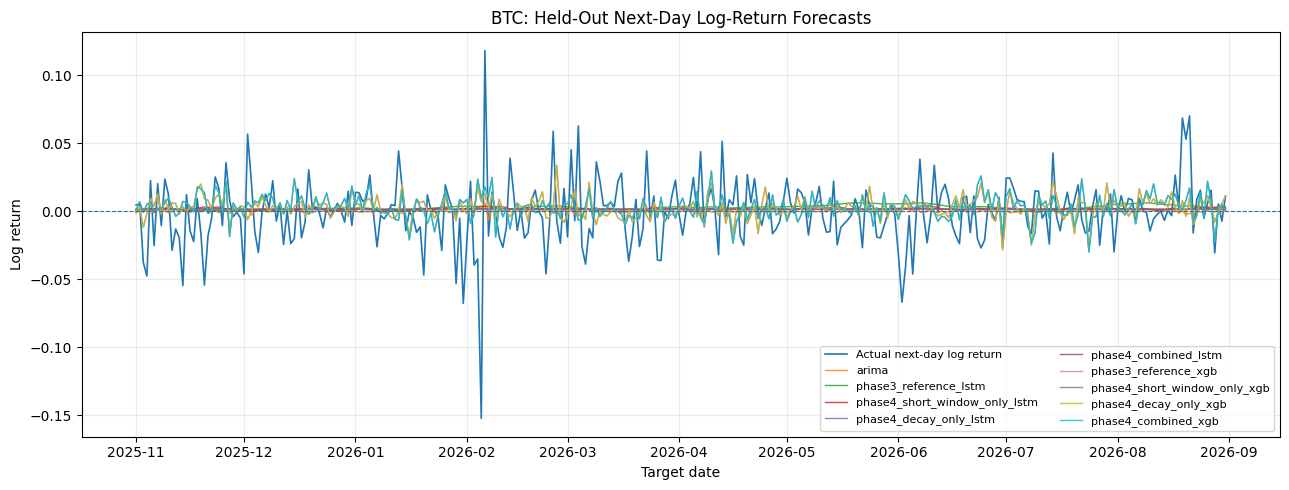

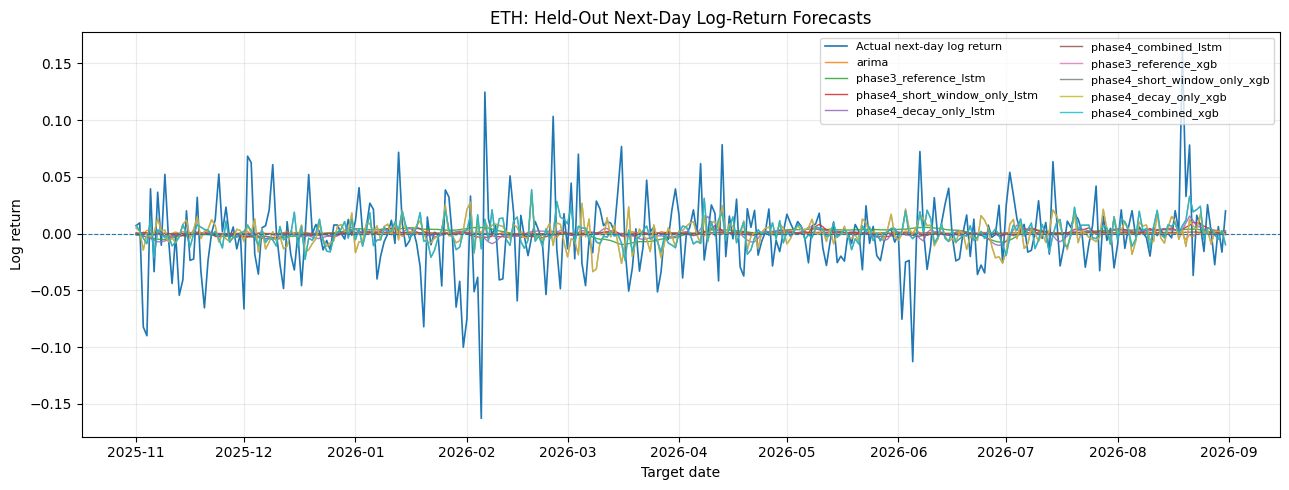

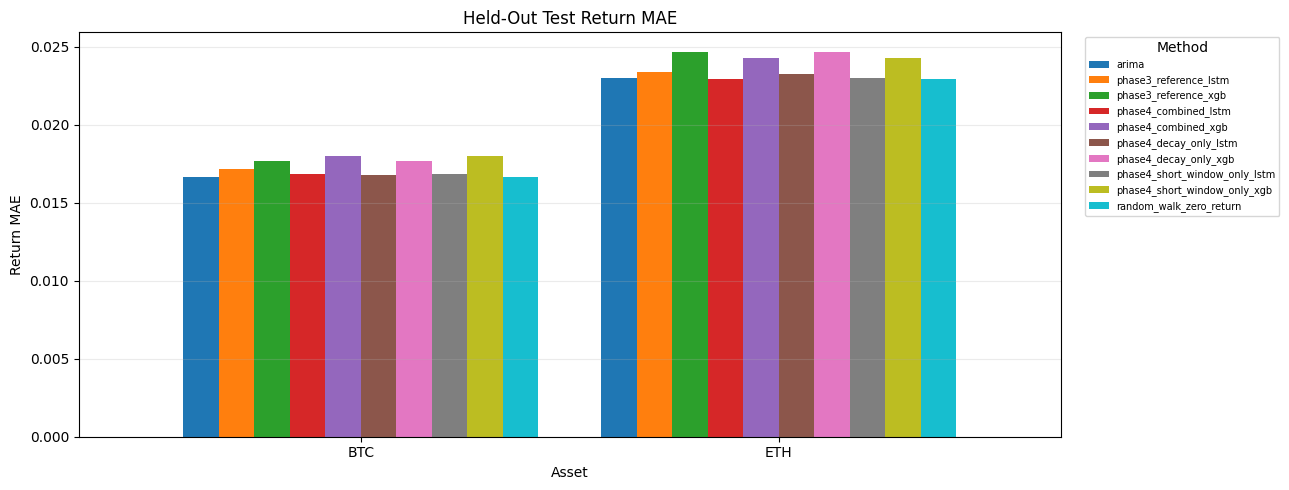

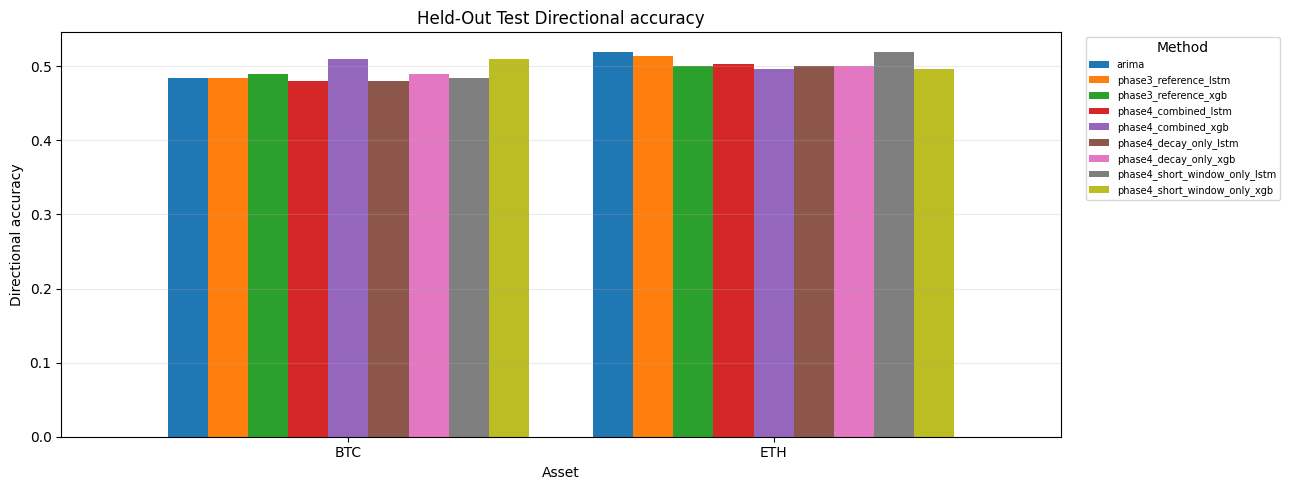

Revised experiment complete.
All tables and figures were saved to: /content/drive/MyDrive/Crypto_Research/revised_outputs/phase4
Primary results are in ensemble_metrics.csv and multiseed_summary.csv.
Statistical tests are in significance.csv; no p-values are hard-coded.


In [ ]:
# Save the exact configuration and package versions used for this run.
if _NEWS_PREPROCESSING_AUDIT:
    news_audit = pd.DataFrame(_NEWS_PREPROCESSING_AUDIT)
    news_audit = news_audit.drop_duplicates().reset_index(drop=True)
    news_audit.to_csv(OUTPUT_DIR / "news_preprocessing_audit.csv", index=False)
    print("Saved news preprocessing audit:", OUTPUT_DIR / "news_preprocessing_audit.csv")

save_configuration(
    {
        "data_start_date": DATA_START_DATE,
        "data_end_date": DATA_END_DATE,
        "expected_news_provider": EXPECTED_NEWS_PROVIDER,
        "filter_automated_market_recaps": FILTER_AUTOMATED_MARKET_RECAPS,
        "automated_recap_filter_strategy": "explicit author metadata, else MarketWatch data-news URL/title-template fallback",
        "split_dates": SPLIT_DATES,
        "seeds": SEEDS,
        "standard_lookback": STANDARD_LOOKBACK,
        "locked_lstm_units": LOCKED_LSTM_UNITS,
        "locked_lstm_dropout": LOCKED_LSTM_DROPOUT,
        "locked_lstm_learning_rate": LOCKED_LSTM_LEARNING_RATE,
        "locked_xgb_n_estimators": LOCKED_XGB_N_ESTIMATORS,
        "locked_xgb_max_depth": LOCKED_XGB_MAX_DEPTH,
        "locked_xgb_learning_rate": LOCKED_XGB_LEARNING_RATE,
        "arima_order_candidates": ARIMA_ORDER_CANDIDATES,
        "vif_threshold": VIF_THRESHOLD,
        "run_walk_forward": RUN_WALK_FORWARD,
    },
    OUTPUT_DIR / "experiment_configuration.json",
)
save_environment_manifest(OUTPUT_DIR / "environment_manifest.json")

plot_test_predictions(
    results["ensemble_predictions"],
    methods=['arima', 'phase3_reference_lstm', 'phase4_short_window_only_lstm', 'phase4_decay_only_lstm', 'phase4_combined_lstm', 'phase3_reference_xgb', 'phase4_short_window_only_xgb', 'phase4_decay_only_xgb', 'phase4_combined_xgb'],
    output_directory=OUTPUT_DIR,
    file_stem="phase4_test_return_predictions",
)
plot_metric_summary(
    results["ensemble_metrics"],
    output_directory=OUTPUT_DIR,
    file_stem="phase4_summary",
)

print("Revised experiment complete.")
print(f"All tables and figures were saved to: {OUTPUT_DIR.resolve()}")
print("Primary results are in ensemble_metrics.csv and multiseed_summary.csv.")
print("Statistical tests are in significance.csv; no p-values are hard-coded.")


## Results to enter after execution

Report each temporal component separately. Do not attribute the combined improvement to temporal weighting alone. Use the paired tests in `significance.csv` and retain the same locked model specifications across all variants.

Use `news_preprocessing_audit.csv` to report the exact duplicate and automated-recap exclusions applied before daily sentiment aggregation.


In [ ]:
import shutil

folder = "/content/drive/MyDrive/Crypto_Research/revised_outputs/phase4"
zip_path = "/content/phase4_outputs"

shutil.make_archive(zip_path, "zip", folder)

print("Created:", zip_path + ".zip")